# HIMS Data — Exploratory Data Analysis (EDA)
**Structure:**
1. Data Overview
2. Data Quality (missing values + the Excel Data Quality Audit)
3. Patient Analysis
4. Hospital Operations (Admissions, LOS, Departments, Wards, Beds)
5. Clinical Analysis (Diseases, Diagnostics, Prescriptions, Drugs)
6. Financial Analysis (Billing, Insurance)
7. Resource Analysis (Doctors, Employees, Staff Shifts)
8. Cross-table Business Insights
9. Final Summary



## Part 1 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


## Part 2 — Load the Excel File


In [ ]:
from google.colab import files
uploaded = files.upload()
file_name = next(iter(uploaded))
xls = pd.ExcelFile(file_name)
print("Excel file loaded successfully!")
print(xls.sheet_names)

Saving HIMS.xlsx to HIMS.xlsx
Excel file loaded successfully!
['admission', 'bed', 'billing', 'billing_details', 'department', 'diagnostic_test', 'disease', 'doctor', 'drug', 'drug_inventory', 'drug_manufacturer', 'employee', 'insurance_provider', 'patient', 'patient_diagnostic', 'patient_insurance', 'prescription', 'staff_assignment', 'ward', 'Data Quality Audit']


## Part 3 — Load All HIMS Tables



In [ ]:
admission            = pd.read_excel(xls, sheet_name="admission")
bed                  = pd.read_excel(xls, sheet_name="bed")
billing              = pd.read_excel(xls, sheet_name="billing")
billing_details      = pd.read_excel(xls, sheet_name="billing_details")
department           = pd.read_excel(xls, sheet_name="department")
diagnostic_test      = pd.read_excel(xls, sheet_name="diagnostic_test")
disease              = pd.read_excel(xls, sheet_name="disease")
doctor               = pd.read_excel(xls, sheet_name="doctor")
drug                 = pd.read_excel(xls, sheet_name="drug")
drug_inventory       = pd.read_excel(xls, sheet_name="drug_inventory")
drug_manufacturer    = pd.read_excel(xls, sheet_name="drug_manufacturer")
employee             = pd.read_excel(xls, sheet_name="employee")
insurance_provider   = pd.read_excel(xls, sheet_name="insurance_provider")
patient              = pd.read_excel(xls, sheet_name="patient")
patient_diagnostic   = pd.read_excel(xls, sheet_name="patient_diagnostic")
patient_insurance    = pd.read_excel(xls, sheet_name="patient_insurance")
prescription         = pd.read_excel(xls, sheet_name="prescription")
staff_assignment     = pd.read_excel(xls, sheet_name="staff_assignment")
ward                 = pd.read_excel(xls, sheet_name="ward")
dq_audit             = pd.read_excel(xls, sheet_name="Data Quality Audit")

print("All HIMS tables loaded successfully!")


All HIMS tables loaded successfully!


In [ ]:
print("Rows before cleaning:", admission.shape[0])
# Drop the spreadsheet "Total" row (admission_id is not numeric for this row)
admission = admission[admission["admission_id"] != "Total"].copy()
admission["admission_id"] = admission["admission_id"].astype(int)
print("Rows after cleaning:", admission.shape[0])   # should now be 45000

Rows before cleaning: 45001
Rows after cleaning: 45000


## Part 4 — Table Sizes (Data Overview)

In [ ]:
tables = {
    "admission": admission,
    "bed": bed,
    "billing": billing,
    "billing_details": billing_details,
    "department": department,
    "diagnostic_test": diagnostic_test,
    "disease": disease,
    "doctor": doctor,
    "drug": drug,
    "drug_inventory": drug_inventory,
    "drug_manufacturer": drug_manufacturer,
    "employee": employee,
    "insurance_provider": insurance_provider,
    "patient": patient,
    "patient_diagnostic": patient_diagnostic,
    "patient_insurance": patient_insurance,
    "prescription": prescription,
    "staff_assignment": staff_assignment,
    "ward": ward,
}

table_summary = pd.DataFrame({
    "Table": tables.keys(),
    "Rows": [df.shape[0] for df in tables.values()],
    "Columns": [df.shape[1] for df in tables.values()],
})

table_summary


,Table,Rows,Columns
0,admission,45000,10
1,bed,415,6
2,billing,45000,8
3,billing_details,112402,7
4,department,11,5
5,diagnostic_test,9,5
6,disease,20,3
7,doctor,98,5
8,drug,250,6
9,drug_inventory,250,6


In [ ]:
admission.info()


<class 'pandas.core.frame.DataFrame'>
Index: 45000 entries, 0 to 44999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   admission_id      45000 non-null  int64         
 1   admission_date    45000 non-null  datetime64[ns]
 2   discharge_date    45000 non-null  datetime64[ns]
 3   admission_type    45000 non-null  object        
 4   admission_status  45000 non-null  object        
 5   patient_id        45000 non-null  float64       
 6   department_id     45000 non-null  float64       
 7   ward_id           45000 non-null  float64       
 8   bed_id            45000 non-null  float64       
 9   disease_id        45000 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(2), object(2)
memory usage: 3.8+ MB


In [ ]:
for name, df in tables.items():
    print("\n================", name, "================")
    print(df.dtypes)



================ admission ================
admission_id                 int64
admission_date      datetime64[ns]
discharge_date      datetime64[ns]
admission_type              object
admission_status            object
patient_id                 float64
department_id              float64
ward_id                    float64
bed_id                     float64
disease_id                   int64
dtype: object

================ bed ================
bed_id                   int64
bed_number              object
bed_status              object
ward_id                  int64
Bed_Number_Check        object
Corrected_Bed_Number    object
dtype: object

================ billing ================
bill_id                              int64
bill_date                   datetime64[ns]
total_amount                         int64
insurance_covered_amount           float64
patient_payable_amount             float64
payment_status                      object
payment_mode                        object
admissio

## Part 6 — Missing-Value Analysis



In [ ]:
missing_summary = []

for name, df in tables.items():
    for column in df.columns:
        missing = df[column].isna().sum()
        missing_percent = (missing / len(df)) * 100
        missing_summary.append([name, column, missing, round(missing_percent, 2)])

missing_df = pd.DataFrame(
    missing_summary,
    columns=["Table", "Column", "Missing Values", "Missing %"]
)

missing_df[missing_df["Missing Values"] > 0]


,Table,Column,Missing Values,Missing %
26,billing_details,reference_id,67402,59.97


In [ ]:
# Your manually-compiled Excel Data Quality Audit
dq_audit


,Table,Issue,Excel Result
0,patient,Mixed contact number types,26319
1,patient,negative contact numbers,1216
2,bed,Bed numbers are interpreted/displayed as dates...,"Date-like values such as 01-Jan, 01-Feb, etc. ..."
3,billing_details,Missing reference_id values,"67,402 missing values are corrected"
4,patient_insurance,Duplicate policy numbers,4 unique policy numbers are duplicated across ...


## Part 7 — Patient Analysis

### 7.1 Patient count

In [ ]:
print("Total Patients:", patient["patient_id"].nunique())


Total Patients: 30000


### 7.2 Gender distribution

gender
Male      15918
Female    13478
Other       604
Name: count, dtype: int64


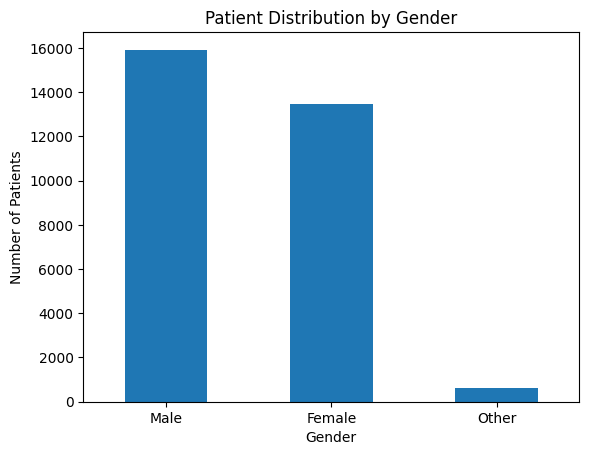

In [ ]:
gender_counts = patient["gender"].value_counts()
print(gender_counts)

gender_counts.plot(kind="bar")
plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()



### 7.3 Blood group distribution

blood_group
O+     3851
AB-    3839
O-     3792
A-     3779
AB+    3752
A+     3730
B+     3695
B-     3562
Name: count, dtype: int64


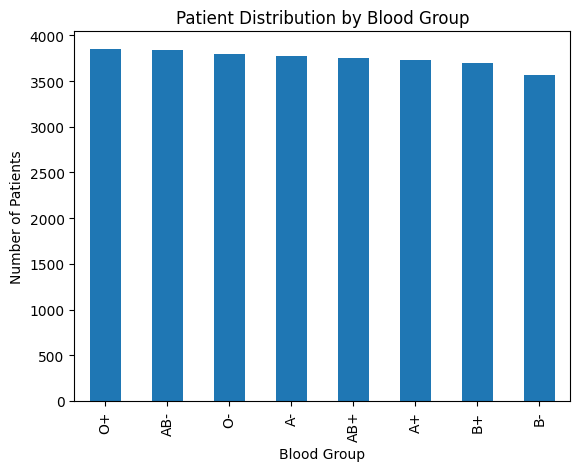

In [ ]:
blood_group_counts = patient["blood_group"].value_counts()
print(blood_group_counts)

blood_group_counts.plot(kind="bar")
plt.title("Patient Distribution by Blood Group")
plt.xlabel("Blood Group")
plt.ylabel("Number of Patients")
plt.show()


### 7.4 Patients by city (top 10)

city
South Michael       32
Port Michael        26
New Michael         26
East Michael        26
South John          25
North Robert        24
West Michael        24
Lake Christopher    23
South David         23
North David         21
Name: count, dtype: int64


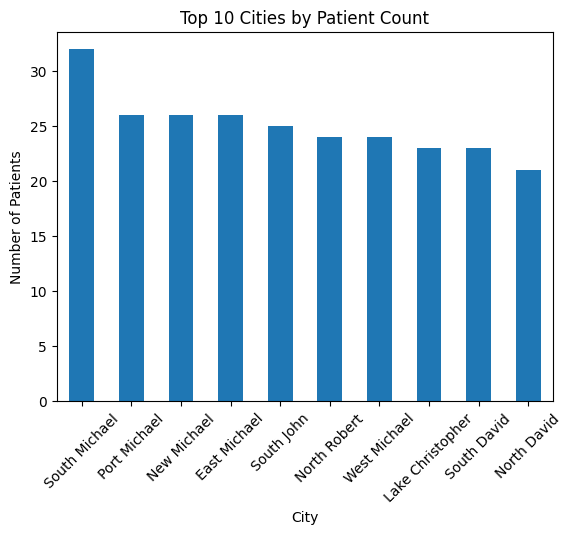

In [ ]:
city_counts = patient["city"].value_counts()
print(city_counts.head(10))

city_counts.head(10).plot(kind="bar")
plt.title("Top 10 Cities by Patient Count")
plt.xlabel("City")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()


## Part 8 — Admission Analysis


In [ ]:
admission["admission_date"] = pd.to_datetime(admission["admission_date"], errors="coerce")
admission["discharge_date"] = pd.to_datetime(admission["discharge_date"], errors="coerce")
print("Total Admissions:", admission["admission_id"].nunique())   # 45,000

Total Admissions: 45000


### 8.1 Admission type

admission_type
Elective     26923
Emergency    18077
Name: count, dtype: int64
admission_type
Elective     59.83
Emergency    40.17
Name: count, dtype: float64


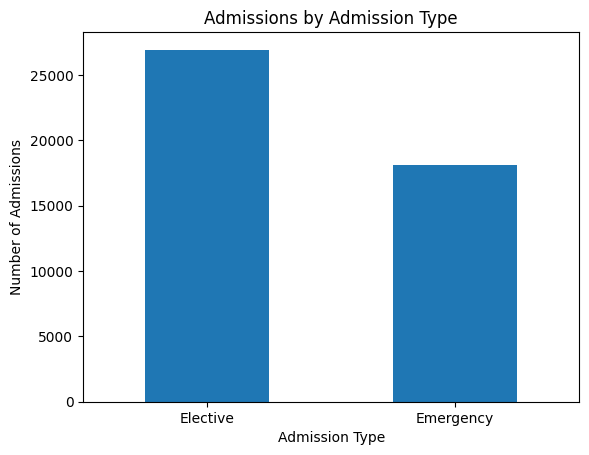

In [ ]:
admission_type = admission["admission_type"].value_counts()
print(admission_type)
print((admission_type / admission_type.sum() * 100).round(2))
admission_type.plot(kind="bar")
plt.title("Admissions by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=0)
plt.show()


### 8.2 Length of Stay

count    45000.000000
mean         5.155000
std          3.271284
min          1.000000
25%          3.000000
50%          4.000000
75%          8.000000
max         15.000000
Name: length_of_stay, dtype: float64
Average LOS: 5.16 days
Median LOS: 4.0 days


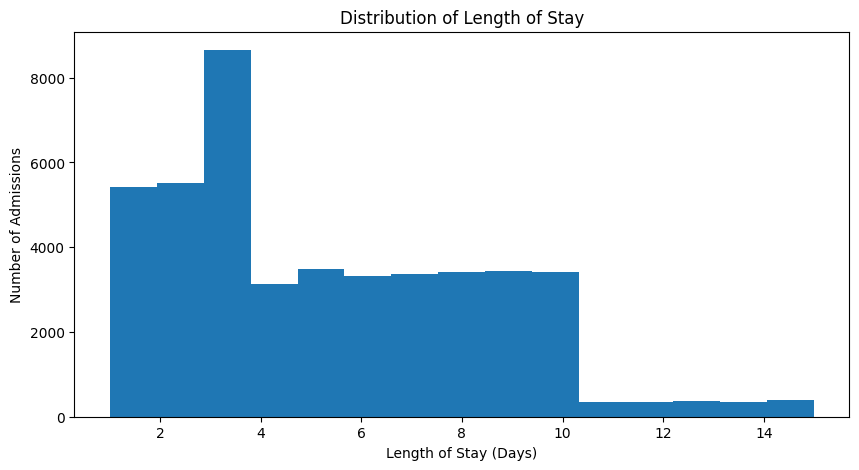

In [ ]:
admission["length_of_stay"] = (admission["discharge_date"] - admission["admission_date"]).dt.days

print(admission["length_of_stay"].describe())
print("Average LOS:", round(admission["length_of_stay"].mean(), 2), "days")
print("Median LOS:", admission["length_of_stay"].median(), "days")

plt.figure(figsize=(10, 5))
plt.hist(admission["length_of_stay"].dropna(), bins=15)
plt.title("Distribution of Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Admissions")
plt.show()


### 8.3 Monthly admission trend


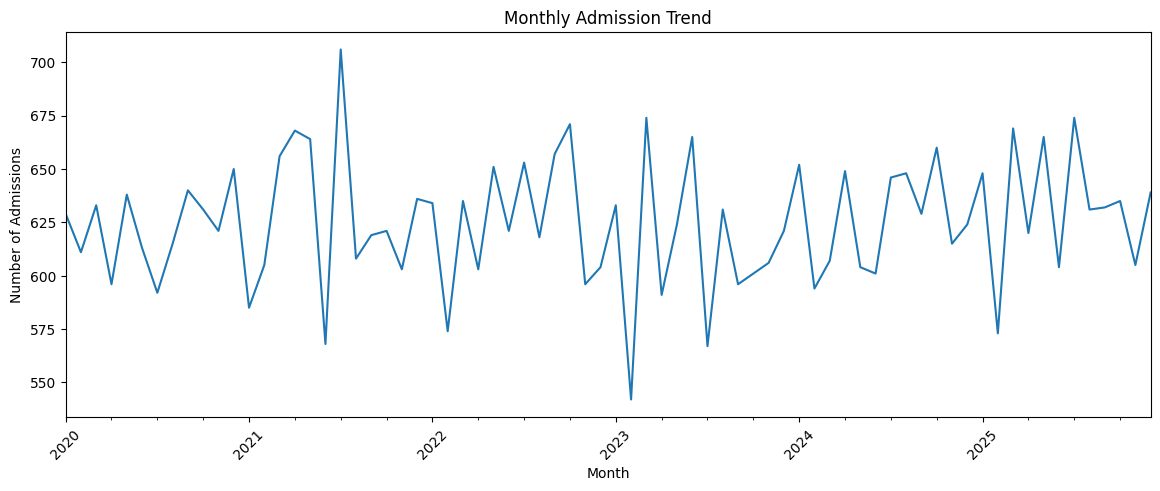

In [ ]:
admission["admission_month"] = admission["admission_date"].dt.to_period("M")
monthly_admissions = admission.groupby("admission_month").size()
plt.figure(figsize=(14, 5))
monthly_admissions.plot(kind="line")
plt.title("Monthly Admission Trend")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.show()


### 8.4 Department analysis

department_name
Surgery              10126
Emergency             8777
Pediatrics            8438
Internal Medicine     7695
Orthopedics           5924
ICU                   4040
Name: count, dtype: int64


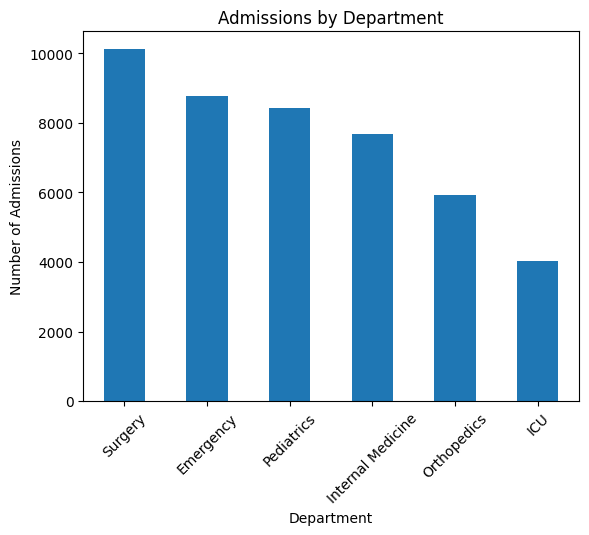

In [ ]:
admission_department = admission.merge(department, on="department_id", how="left")

department_admissions = admission_department["department_name"].value_counts()
print(department_admissions)

department_admissions.plot(kind="bar")
plt.title("Admissions by Department")
plt.xlabel("Department")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.show()


### 8.5 Average Length of Stay by Department

In [ ]:
department_los = (
    admission_department
    .groupby("department_name")["length_of_stay"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
department_los


,count,mean,median
department_name,,,
ICU,4040,9.980693,10.0
Emergency,8777,4.692492,4.0
Pediatrics,8438,4.691752,4.0
Orthopedics,5924,4.677920,4.0
Surgery,10126,4.674798,4.0
Internal Medicine,7695,4.656140,4.0


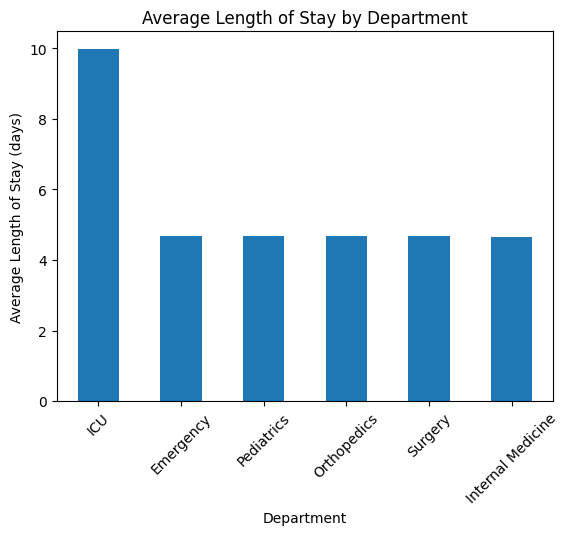

In [ ]:
department_los["mean"].plot(kind="bar")
plt.title("Average Length of Stay by Department")
plt.xlabel("Department")
plt.ylabel("Average Length of Stay (days)")
plt.xticks(rotation=45)
plt.show()


### 8.6 Ward and bed analysis


bed_status
Occupied     270
Available    145
Name: count, dtype: int64


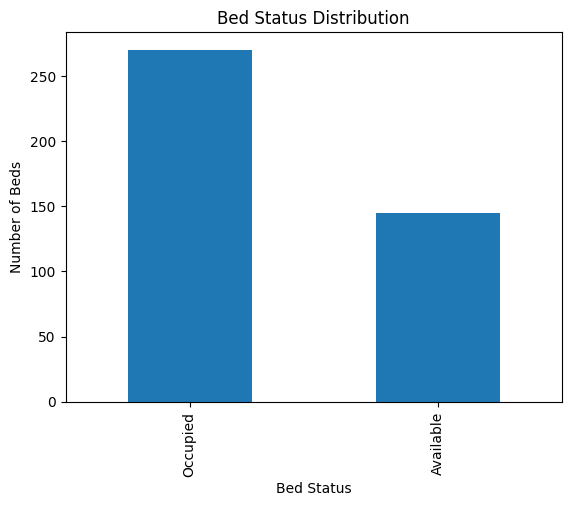

In [ ]:
print(bed["bed_status"].value_counts())
bed["bed_status"].value_counts().plot(kind="bar")
plt.title("Bed Status Distribution")
plt.xlabel("Bed Status")
plt.ylabel("Number of Beds")
plt.show()

ward_name
Pediatrics Ward 2           2228
Emergency Ward 4            2227
Emergency Ward 5            2212
Orthopedics Ward 3          2207
Internal Medicine Ward 5    2168
Surgery Ward 2              2157
Surgery Ward 3              2147
Surgery Ward 1              2140
Surgery Ward 4              1895
Pediatrics Ward 3           1881
Internal Medicine Ward 2    1873
Orthopedics Ward 1          1868
Emergency Ward 2            1867
Orthopedics Ward 2          1849
Pediatrics Ward 5           1843
Surgery Ward 5              1787
Pediatrics Ward 4           1266
Emergency Ward 1            1265
ICU Ward 2                  1246
ICU Ward 4                  1241
Internal Medicine Ward 1    1225
Pediatrics Ward 1           1220
Internal Medicine Ward 3    1220
Internal Medicine Ward 4    1209
Emergency Ward 3            1206
ICU Ward 3                   939
ICU Ward 1                   614
Name: count, dtype: int64


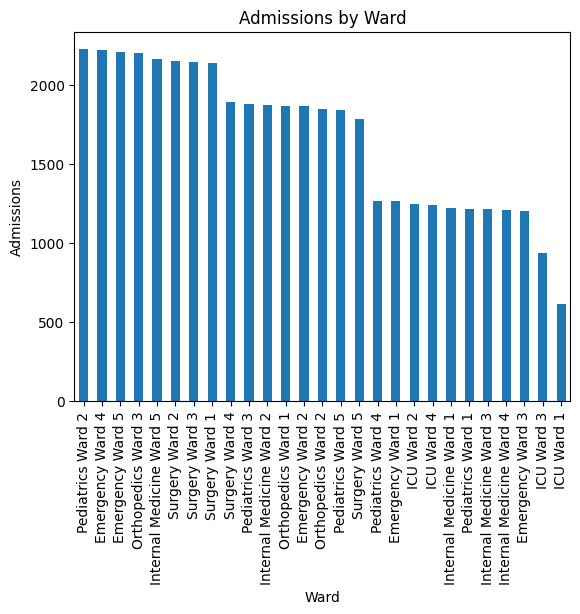

In [ ]:
admission_ward = admission.merge(ward, on="ward_id", how="left")
ward_admissions = admission_ward["ward_name"].value_counts()
print(ward_admissions)
ward_admissions.plot(kind="bar")
plt.title("Admissions by Ward")
plt.xlabel("Ward")
plt.ylabel("Admissions")
plt.xticks(rotation=90)
plt.show()


## Part 9 — Disease Analysis

disease_name
Stroke                                   2300
Sepsis                                   2297
Chronic Obstructive Pulmonary Disease    2289
Fracture Femur                           2288
Acute Myocardial Infarction              2282
Acute Respiratory Distress               2275
Gallstones                               2271
Urinary Tract Infection                  2259
Tuberculosis                             2256
Road Traffic Accident                    2253
Name: count, dtype: int64


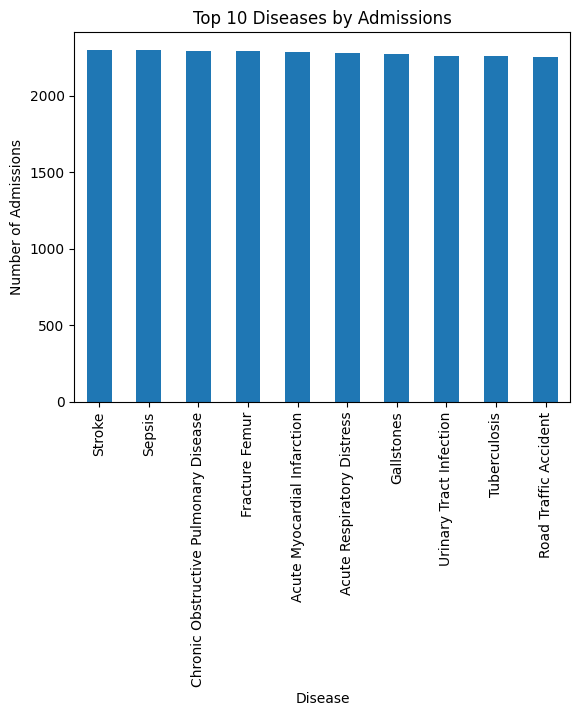

In [ ]:
admission_disease = admission.merge(disease, on="disease_id", how="left")

top_diseases = admission_disease["disease_name"].value_counts().head(10)
print(top_diseases)

top_diseases.plot(kind="bar")
plt.title("Top 10 Diseases by Admissions")
plt.xlabel("Disease")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=90)
plt.show()


disease_category
Infectious       11248
Surgical          6711
Respiratory       4564
Cardiac           4525
Pediatric         4436
Neurological      2300
Orthopedic        2288
Trauma            2253
Renal             2251
Hematological     2235
Endocrine         2189
Name: count, dtype: int64


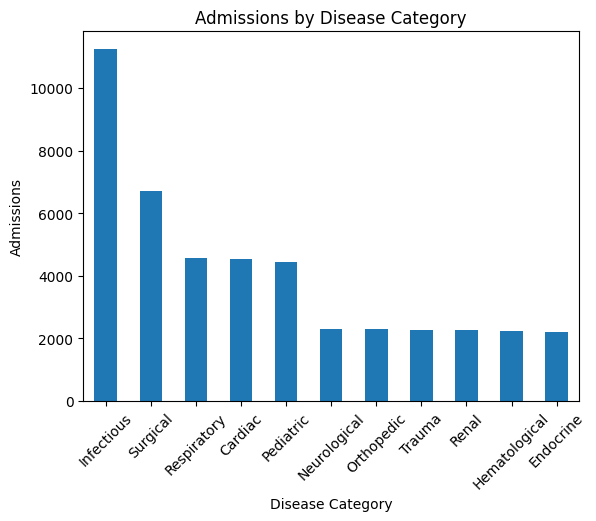

In [ ]:
disease_category = admission_disease["disease_category"].value_counts()
print(disease_category)
disease_category.plot(kind="bar")
plt.title("Admissions by Disease Category")
plt.xlabel("Disease Category")
plt.ylabel("Admissions")
plt.xticks(rotation=45)
plt.show()


## Part 10 — Diagnostic Test Analysis

result_status
Abnormal    31823
Normal      31446
Name: count, dtype: int64


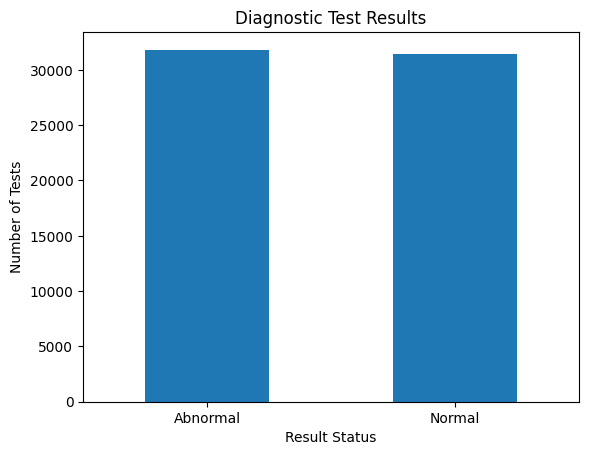

In [ ]:
diagnostic_results = patient_diagnostic["result_status"].value_counts()
print(diagnostic_results)

diagnostic_results.plot(kind="bar")
plt.title("Diagnostic Test Results")
plt.xlabel("Result Status")
plt.ylabel("Number of Tests")
plt.xticks(rotation=0)
plt.show()


test_name
Complete Blood Count    7086
Kidney Function Test    7065
X-Ray Chest             7064
MRI Spine               7061
Lipid Profile           7039
Liver Function Test     7031
CT Scan Brain           7017
Blood Sugar             6961
Ultrasound Abdomen      6945
Name: count, dtype: int64


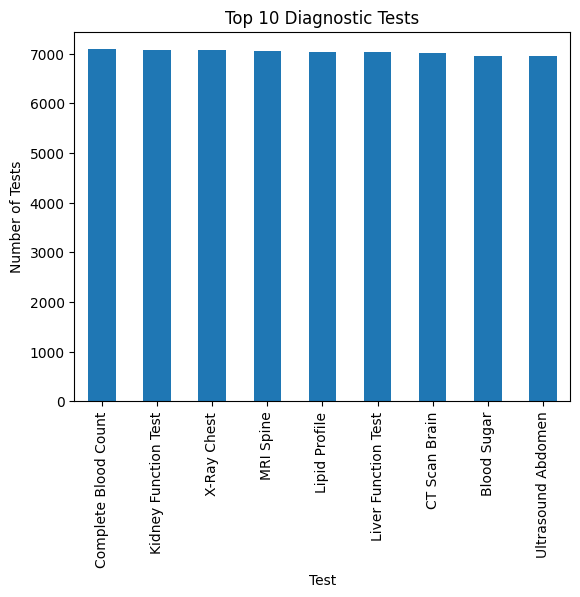

In [ ]:
diagnostic_analysis = patient_diagnostic.merge(diagnostic_test, on="test_id", how="left")
top_tests = diagnostic_analysis["test_name"].value_counts().head(10)
print(top_tests)
top_tests.plot(kind="bar")
plt.title("Top 10 Diagnostic Tests")
plt.xlabel("Test")
plt.ylabel("Number of Tests")
plt.xticks(rotation=90)
plt.show()


## Part 11 — Prescription & Drug Analysis

Total Prescriptions: 73109


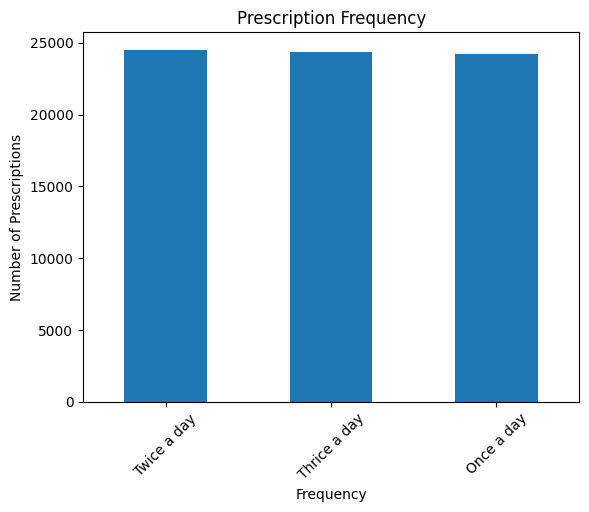

In [ ]:
print("Total Prescriptions:", prescription["prescription_id"].nunique())
prescription["frequency"].value_counts().plot(kind="bar")
plt.title("Prescription Frequency")
plt.xlabel("Frequency")
plt.ylabel("Number of Prescriptions")
plt.xticks(rotation=45)
plt.show()


drug_name
Nostrum     1788
Officiis    1502
Sint        1486
Minus       1177
Maxime      1163
Iusto       1152
Nam         1143
Eius        1129
Harum       1108
Iste         936
Name: count, dtype: int64


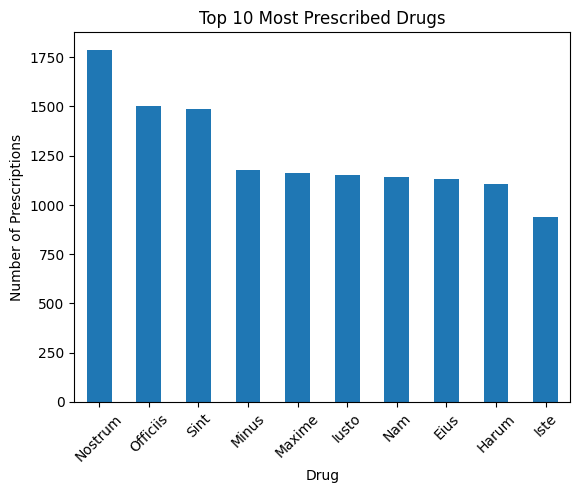

In [ ]:
prescription_drug = prescription.merge(drug, on="drug_id", how="left")
top_drugs = prescription_drug["drug_name"].value_counts().head(10)
print(top_drugs)
top_drugs.plot(kind="bar")
plt.title("Top 10 Most Prescribed Drugs")
plt.xlabel("Drug")
plt.ylabel("Number of Prescriptions")
plt.xticks(rotation=45)
plt.show()


### Drug inventory

inventory_status
Normal    206
Low        44
Name: count, dtype: int64


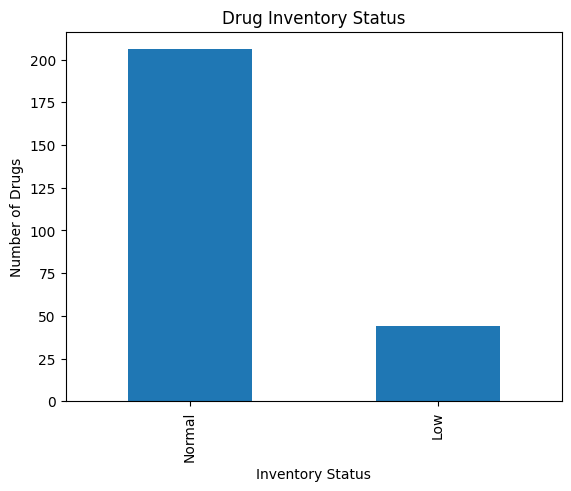

Low Stock Percentage: 17.6 %


In [ ]:
inventory_status = drug_inventory["inventory_status"].value_counts()
print(inventory_status)
inventory_status.plot(kind="bar")
plt.title("Drug Inventory Status")
plt.xlabel("Inventory Status")
plt.ylabel("Number of Drugs")
plt.show()
low_stock = (drug_inventory["inventory_status"] == "Low").sum()
total_inventory = len(drug_inventory)
print("Low Stock Percentage:", round(low_stock / total_inventory * 100, 2), "%")


## Part 12 — Billing & Financial Analysis



In [ ]:
billing["total_amount"] = pd.to_numeric(billing["total_amount"], errors="coerce")
billing["insurance_covered_amount"] = pd.to_numeric(billing["insurance_covered_amount"], errors="coerce")
billing["patient_payable_amount"] = pd.to_numeric(billing["patient_payable_amount"], errors="coerce")
total_billing = billing["total_amount"].sum()
print("Total Billing Amount:", total_billing)

Total Billing Amount: 1684246109


Insurance Covered: 976880867.0
Patient Payable: 707365242.0


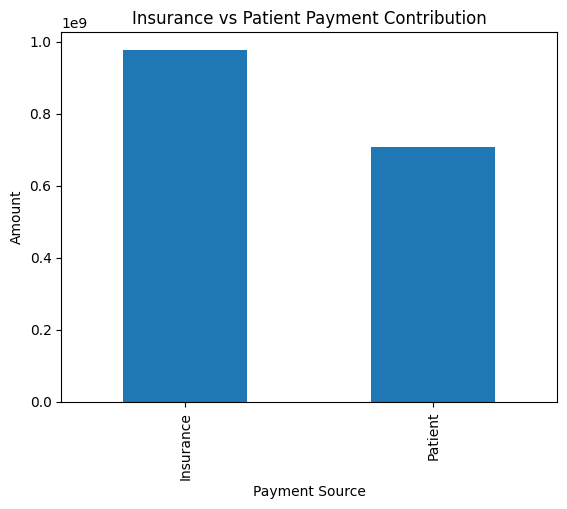

In [ ]:
insurance_amount = billing["insurance_covered_amount"].sum()
patient_amount = billing["patient_payable_amount"].sum()
print("Insurance Covered:", insurance_amount)
print("Patient Payable:", patient_amount)
pd.Series({"Insurance": insurance_amount, "Patient": patient_amount}).plot(kind="bar")
plt.title("Insurance vs Patient Payment Contribution")
plt.xlabel("Payment Source")
plt.ylabel("Amount")
plt.show()


payment_status
Pending    22670
Paid       22330
Name: count, dtype: int64


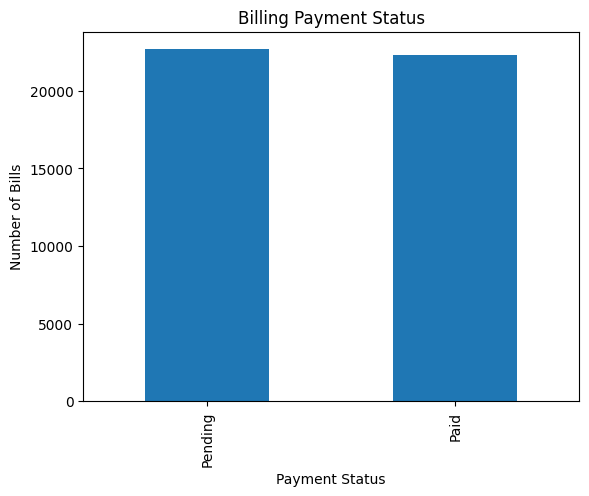

In [ ]:
payment_status = billing["payment_status"].value_counts()
print(payment_status)
payment_status.plot(kind="bar")
plt.title("Billing Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Number of Bills")
plt.show()


**Confirmed:** Pending 22,670 vs Paid 22,330.

payment_mode
Insurance    35979
UPI           3049
Card          3017
Cash          2955
Name: count, dtype: int64


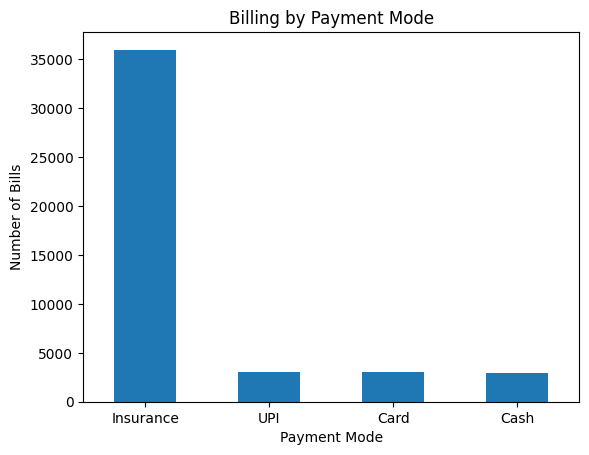

In [ ]:
payment_mode = billing["payment_mode"].value_counts()
print(payment_mode)
payment_mode.plot(kind="bar")
plt.title("Billing by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Bills")
plt.xticks(rotation=0)
plt.show()


In [ ]:
charge_analysis = (
    billing_details
    .groupby("charge_type")["amount"]
    .agg(Number_of_Charges="count", Total_Amount="sum", Average_Amount="mean")
    .sort_values("Total_Amount", ascending=False)
)
charge_analysis


,Number_of_Charges,Total_Amount,Average_Amount
charge_type,,,
Room,45000,1162571584,25834.924089
Procedure,13575,204517073,15065.714401
Test,22483,61725515,2745.430548
Drug,31344,50066094,1597.310299


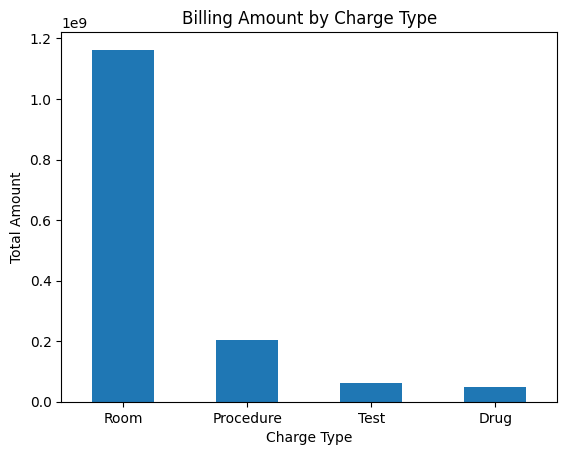

In [ ]:
charge_analysis["Total_Amount"].plot(kind="bar")
plt.title("Billing Amount by Charge Type")
plt.xlabel("Charge Type")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.show()


### Insurance providers


provider_name
Borah, Parmer and Varty Health Insurance      469
Chauhan, Kakar and Saxena Health Insurance    466
Chandra PLC Health Insurance                  460
Loyal, Parikh and Bajwa Health Insurance      459
Pillai Ltd Health Insurance                   458
Upadhyay-Dalal Health Insurance               457
Gade LLC Health Insurance                     456
Shah, Ghose and Sankar Health Insurance       455
Banerjee, Chad and Nath Health Insurance      454
Andra LLC Health Insurance                    454
Name: count, dtype: int64


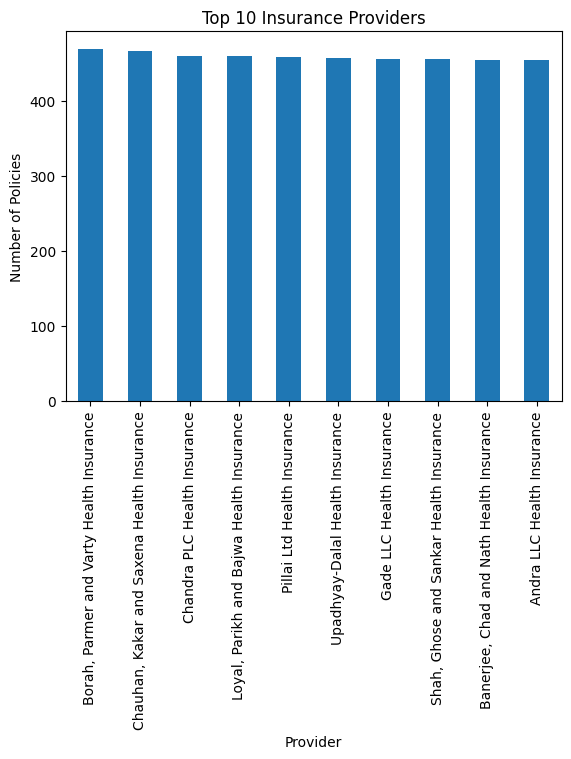

In [ ]:
insurance_analysis = patient_insurance.merge(insurance_provider, on="insurance_provider_id", how="left")
top_providers = insurance_analysis["provider_name"].value_counts().head(10)
print(top_providers)
top_providers.plot(kind="bar")
plt.title("Top 10 Insurance Providers")
plt.xlabel("Provider")
plt.ylabel("Number of Policies")
plt.xticks(rotation=90)
plt.show()


## Part 13 — Resource Analysis (Employees, Doctors, Staff Shifts)

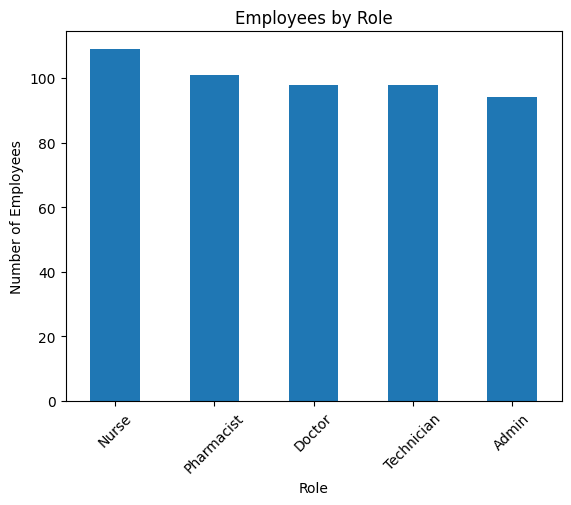

role
Nurse         109
Pharmacist    101
Doctor         98
Technician     98
Admin          94
Name: count, dtype: int64


In [ ]:
employee["role"].value_counts().plot(kind="bar")
plt.title("Employees by Role")
plt.xlabel("Role")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()
print(employee["role"].value_counts())


**Confirmed:** Nurse 109 · Pharmacist 101 · Doctor 98 · Technician 98 · Admin 94.

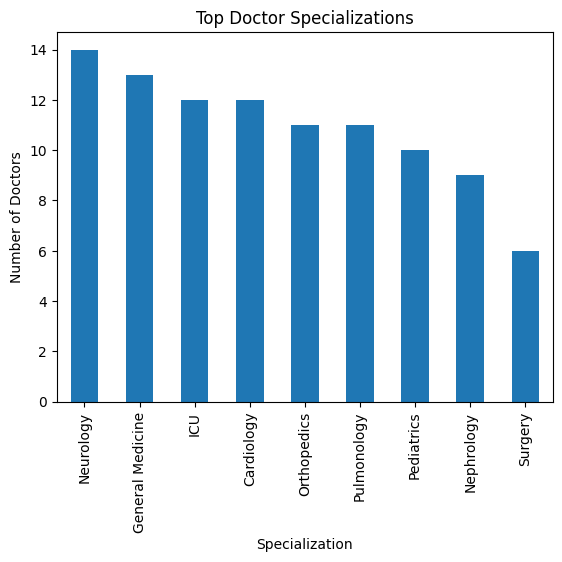

count    98.000000
mean     17.428571
std      10.404202
min       1.000000
25%       8.000000
50%      17.500000
75%      26.000000
max      35.000000
Name: experience_years, dtype: float64


In [ ]:
doctor["specialization"].value_counts().head(10).plot(kind="bar")
plt.title("Top Doctor Specializations")
plt.xlabel("Specialization")
plt.ylabel("Number of Doctors")
plt.xticks(rotation=90)
plt.show()
print(doctor["experience_years"].describe())


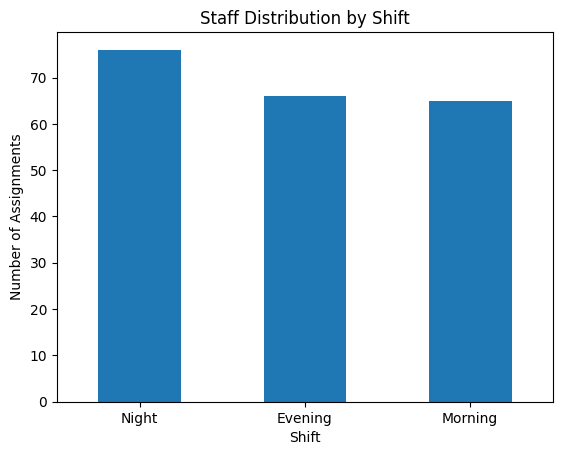

shift
Night      76
Evening    66
Morning    65
Name: count, dtype: int64


In [ ]:
staff_assignment["shift"].value_counts().plot(kind="bar")
plt.title("Staff Distribution by Shift")
plt.xlabel("Shift")
plt.ylabel("Number of Assignments")
plt.xticks(rotation=0)
plt.show()

print(staff_assignment["shift"].value_counts())


### Length of Stay vs Billing



                length_of_stay  total_amount
length_of_stay        1.000000      0.001309
total_amount          0.001309      1.000000


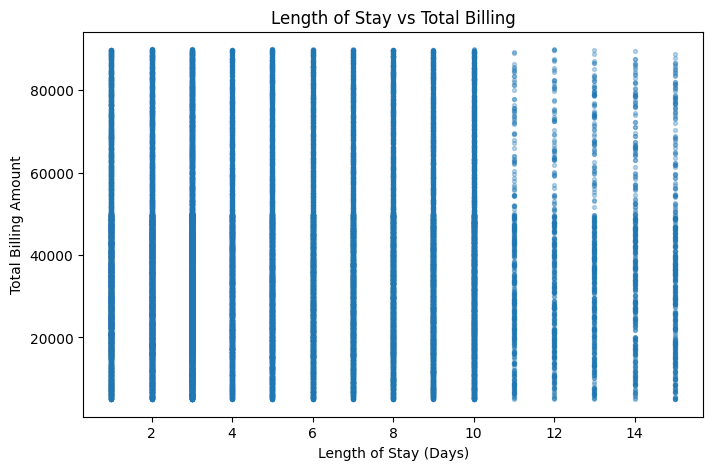

In [ ]:
billing_los = billing.merge(admission[["admission_id", "length_of_stay"]], on="admission_id", how="left")
correlation = billing_los[["length_of_stay", "total_amount"]].corr()
print(correlation)
plt.figure(figsize=(8, 5))
plt.scatter(billing_los["length_of_stay"], billing_los["total_amount"], alpha=0.3, s=8)
plt.title("Length of Stay vs Total Billing")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Total Billing Amount")
plt.show()


### Billing trend by admission month



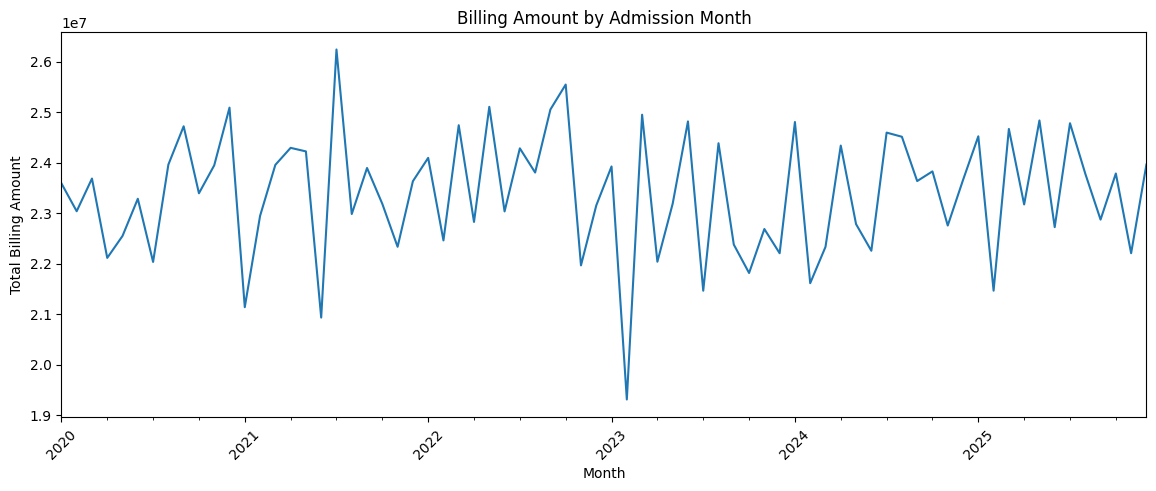

In [ ]:
billing_admission = billing.merge(admission[["admission_id", "admission_date"]], on="admission_id", how="left")
billing_admission["admission_month"] = billing_admission["admission_date"].dt.to_period("M")
monthly_billing = billing_admission.groupby("admission_month")["total_amount"].sum()
monthly_billing.plot(figsize=(14, 5), kind="line")
plt.title("Billing Amount by Admission Month")
plt.xlabel("Month")
plt.ylabel("Total Billing Amount")
plt.xticks(rotation=45)
plt.show()


## Part 15 — Final EDA Summary

In [ ]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Patients",
        "Total Admissions",
        "Total Bills",
        "Total Prescriptions",
        "Total Diagnostic Tests",
        "Total Billing Amount",
        "Average Length of Stay (days)",
        "Pending Bills",
        "Low Stock Drugs",
    ],
    "Value": [
        patient["patient_id"].nunique(),
        admission["admission_id"].nunique(),
        billing["bill_id"].nunique(),
        prescription["prescription_id"].nunique(),
        patient_diagnostic["patient_diagnostic_id"].nunique(),
        billing["total_amount"].sum(),
        round(admission["length_of_stay"].mean(), 2),
        (billing["payment_status"] == "Pending").sum(),
        (drug_inventory["inventory_status"] == "Low").sum(),
    ],
})

eda_summary


,Metric,Value
0,Total Patients,3.000000e+04
1,Total Admissions,4.500000e+04
2,Total Bills,4.500000e+04
3,Total Prescriptions,7.310900e+04
4,Total Diagnostic Tests,6.326900e+04
5,Total Billing Amount,1.684246e+09
6,Average Length of Stay (days),5.160000e+00
7,Pending Bills,2.267000e+04
8,Low Stock Drugs,4.400000e+01


## Business Insights (fill in the numbers your run produces)

- Elective admissions (26,923) outnumber Emergency admissions (18,077) roughly 3-to-2.
- Average length of stay is ~5.16 days, with a right-skewed distribution (median 4, max 15) — a small
  share of long-stay cases pull the mean up.
- Diagnostic results are almost evenly split, with Abnormal (31,823) very slightly ahead of Normal (31,446).
- 17.6% of drugs are in "Low" inventory status — a real replenishment risk worth flagging to the pharmacy team.
- Billing is nearly split down the middle between Paid (22,330) and Pending (22,670) — worth investigating
  *why* pending bills are onboard, since it's marginally the larger group.
- Insurance is by far the dominant payment mode (35,979 of ~45,000 bills) — cash/card/UPI are minor by comparison.
- Check the length-of-stay vs. billing correlation coefficient from Part 14 before stating a relationship —
  report the actual number rather than assuming it's strong.

**Data-quality caveats to disclose in your report:** the dropped "Total" row in `admission`, the corrected
bed-number and reference-ID columns, the duplicated policy numbers, and the mixed/negative patient contact
numbers. Mentioning these shows you audited the data rather than assuming it was clean.
